<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-09-25 15:43:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  40.8MB/s    in 3.6s    

2026-09-25 15:43:35 (41.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


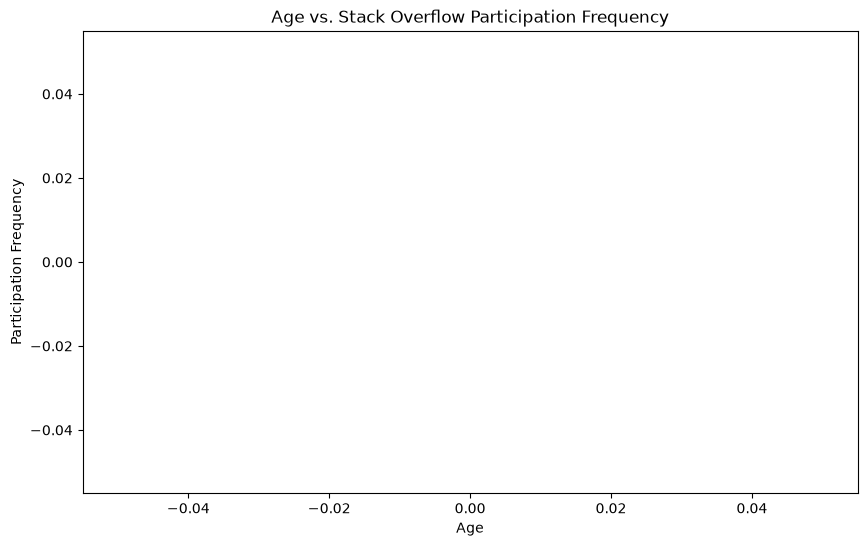

In [3]:
##Write your code here
# Convert Age groups to numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df["Age_numeric"] = df["Age"].map(age_mapping)

# Convert JobSat to numeric
df["JobSat_numeric"] = pd.to_numeric(
    df["JobSat"],
    errors="coerce"
)

# Convert SOPartFreq to numeric
df["SOPartFreq_numeric"] = pd.to_numeric(
    df["SOPartFreq"],
    errors="coerce"
)

# Select required data
plot_data = df[
    [
        "Age_numeric",
        "SOPartFreq_numeric",
        "JobSat_numeric"
    ]
].dropna()

# Create bubble plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["Age_numeric"],
    plot_data["SOPartFreq_numeric"],
    s=plot_data["JobSat_numeric"] * 30,
    alpha=0.5
)

plt.title(
    "Age vs. Stack Overflow Participation Frequency"
)

plt.xlabel("Age")
plt.ylabel("Participation Frequency")

plt.show()

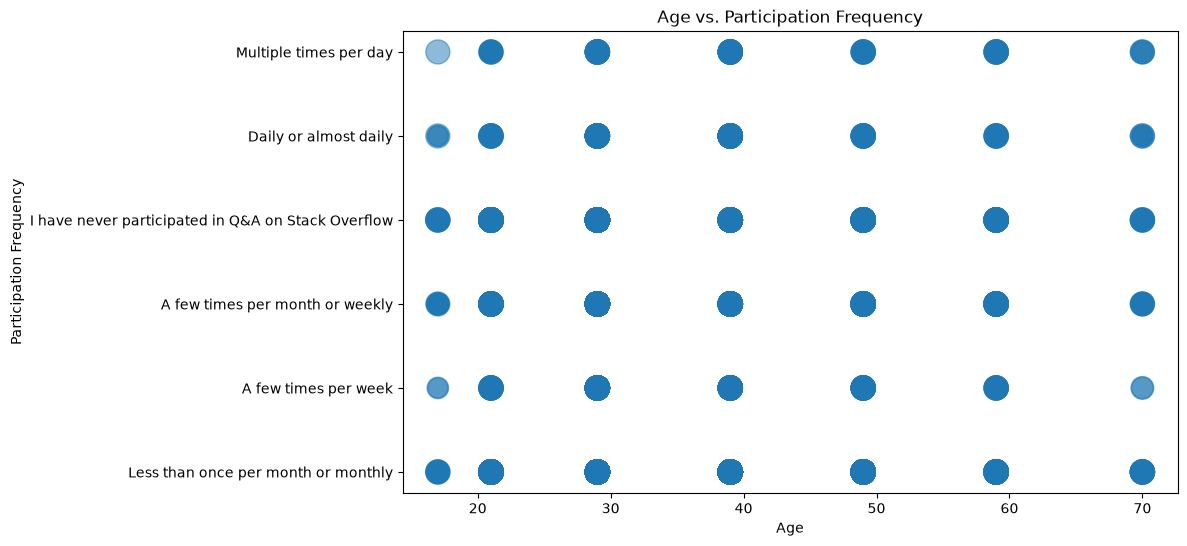

In [4]:
# Count participation frequency categories
freq_counts = df["SOPartFreq"].value_counts()

freq_data = df[
    ["Age_numeric", "SOPartFreq", "JobSat_numeric"]
].dropna()

# Convert participation categories to numeric positions
freq_categories = freq_data["SOPartFreq"].unique()

freq_mapping = {
    value: i + 1
    for i, value in enumerate(freq_categories)
}

freq_data["Freq_numeric"] = (
    freq_data["SOPartFreq"].map(freq_mapping)
)

plt.figure(figsize=(10, 6))

plt.scatter(
    freq_data["Age_numeric"],
    freq_data["Freq_numeric"],
    s=freq_data["JobSat_numeric"] * 30,
    alpha=0.5
)

plt.title(
    "Age vs. Participation Frequency"
)

plt.xlabel("Age")
plt.ylabel("Participation Frequency")

plt.yticks(
    range(1, len(freq_categories) + 1),
    freq_categories
)

plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


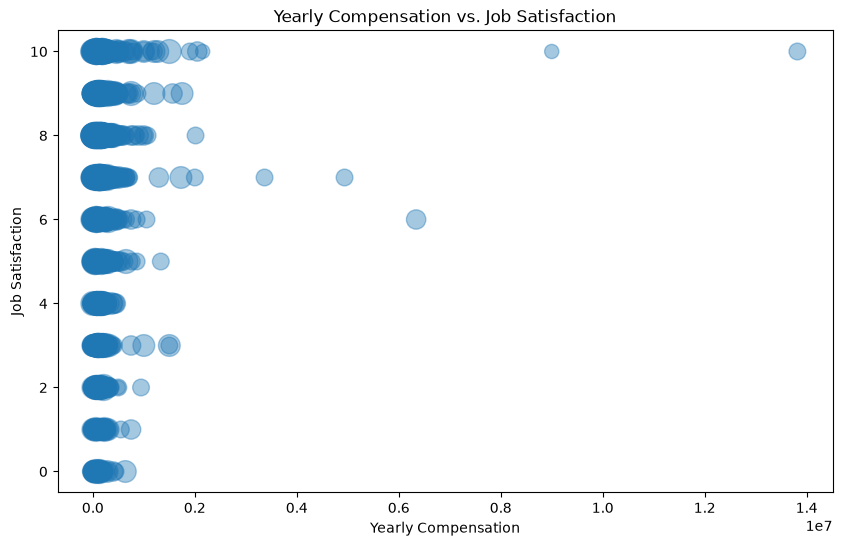

In [5]:
##Write your code here
# Convert compensation to numeric
df["ConvertedCompYearly"] = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
)

# Select required data
plot_data = df[
    [
        "ConvertedCompYearly",
        "JobSat_numeric",
        "Age_numeric"
    ]
].dropna()

# Create bubble plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["ConvertedCompYearly"],
    plot_data["JobSat_numeric"],
    s=plot_data["Age_numeric"] * 5,
    alpha=0.4
)

plt.title(
    "Yearly Compensation vs. Job Satisfaction"
)

plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")

plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



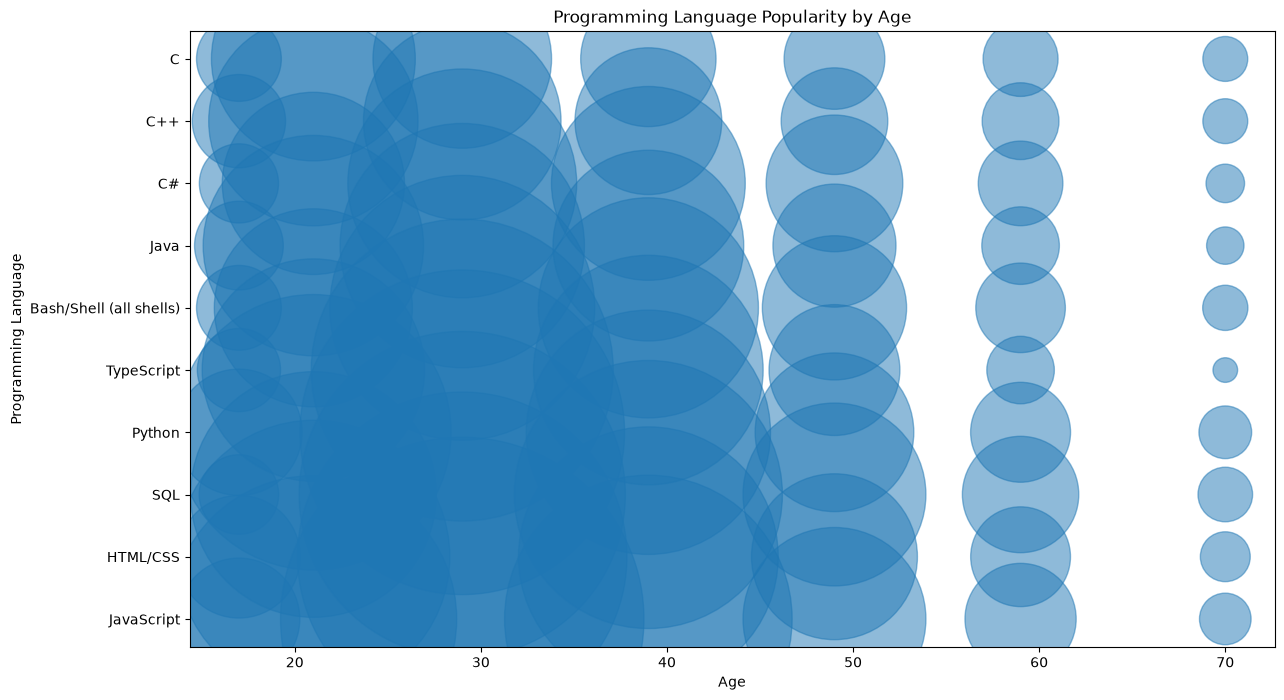

In [6]:
##Write your code here
# Select required columns
language_data = df[
    ["Age_numeric", "LanguageHaveWorkedWith"]
].dropna()

# Split multiple languages
language_data["Language"] = (
    language_data["LanguageHaveWorkedWith"]
    .str.split(";")
)

# Create one row per language
language_data = language_data.explode(
    "Language"
)

# Remove extra spaces
language_data["Language"] = (
    language_data["Language"]
    .str.strip()
)

# Count language usage by age
language_counts = (
    language_data
    .groupby(["Age_numeric", "Language"])
    .size()
    .reset_index(name="Frequency")
)

# Keep top 10 languages overall
top_languages = (
    language_data["Language"]
    .value_counts()
    .head(10)
    .index
)

language_counts = language_counts[
    language_counts["Language"].isin(top_languages)
]

# Create numeric positions for languages
language_positions = {
    language: i
    for i, language in enumerate(top_languages)
}

language_counts["Language_Position"] = (
    language_counts["Language"]
    .map(language_positions)
)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    language_counts["Age_numeric"],
    language_counts["Language_Position"],
    s=language_counts["Frequency"] * 5,
    alpha=0.5
)

plt.title(
    "Programming Language Popularity by Age"
)

plt.xlabel("Age")
plt.ylabel("Programming Language")

plt.yticks(
    range(len(top_languages)),
    top_languages
)

plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


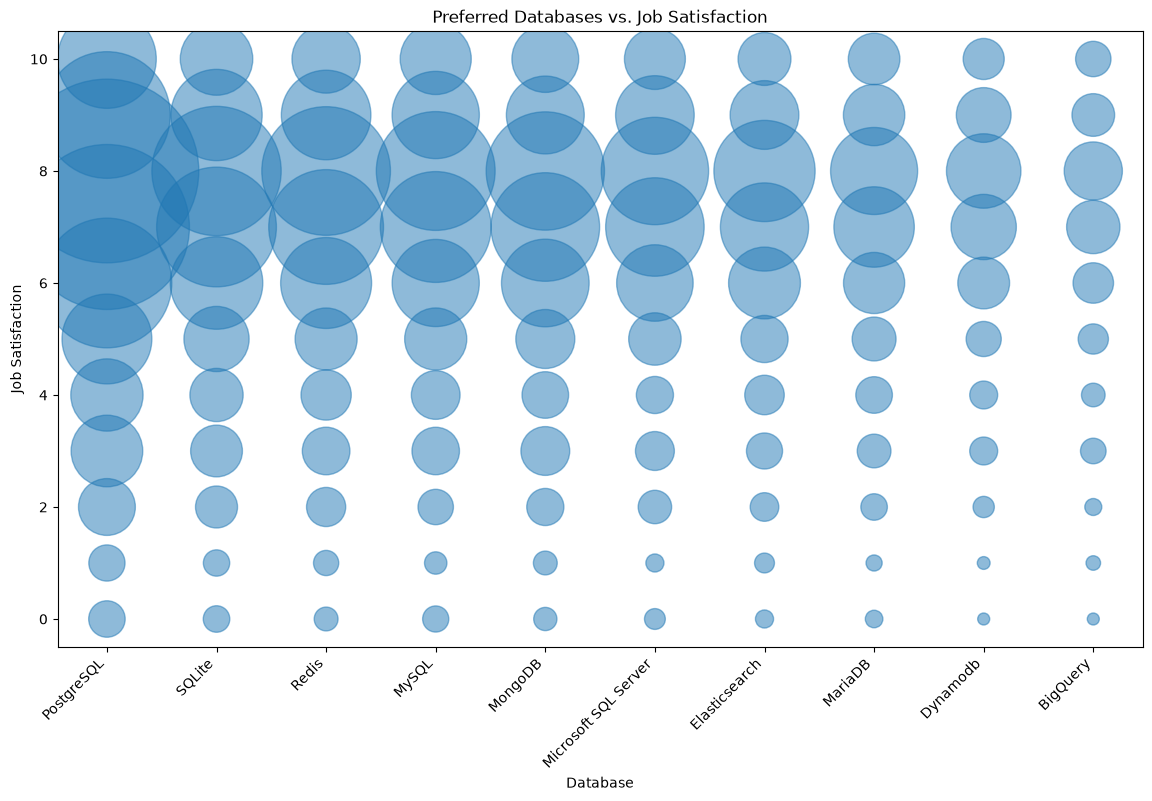

In [7]:
##Write your code here
# Select database and job satisfaction
database_data = df[
    [
        "DatabaseWantToWorkWith",
        "JobSat_numeric"
    ]
].dropna()

# Split multiple databases
database_data["Database"] = (
    database_data["DatabaseWantToWorkWith"]
    .str.split(";")
)

# Create one row per database
database_data = database_data.explode(
    "Database"
)

database_data["Database"] = (
    database_data["Database"]
    .str.strip()
)

# Calculate number of respondents
database_summary = (
    database_data
    .groupby(["Database", "JobSat_numeric"])
    .size()
    .reset_index(name="Frequency")
)

# Select top 10 databases
top_databases = (
    database_data["Database"]
    .value_counts()
    .head(10)
    .index
)

database_summary = database_summary[
    database_summary["Database"].isin(
        top_databases
    )
]

# Create positions for databases
database_positions = {
    database: i
    for i, database in enumerate(top_databases)
}

database_summary["Database_Position"] = (
    database_summary["Database"]
    .map(database_positions)
)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    database_summary["Database_Position"],
    database_summary["JobSat_numeric"],
    s=database_summary["Frequency"] * 5,
    alpha=0.5
)

plt.title(
    "Preferred Databases vs. Job Satisfaction"
)

plt.xlabel("Database")
plt.ylabel("Job Satisfaction")

plt.xticks(
    range(len(top_databases)),
    top_databases,
    rotation=45,
    ha="right"
)

plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


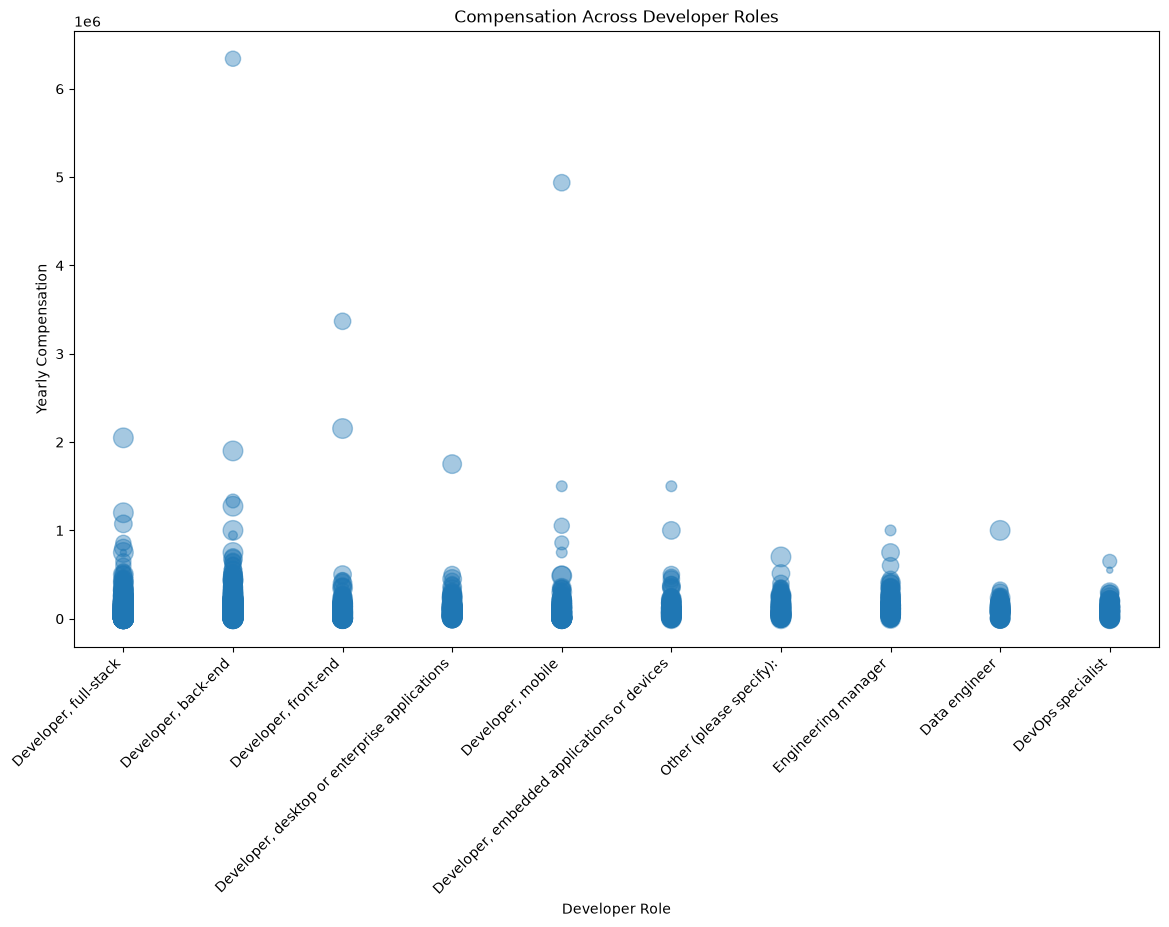

In [8]:
##Write your code here
# Select required data
dev_data = df[
    [
        "DevType",
        "ConvertedCompYearly",
        "JobSat_numeric"
    ]
].dropna()

# Split multiple developer roles
dev_data["DeveloperRole"] = (
    dev_data["DevType"]
    .str.split(";")
)

dev_data = dev_data.explode(
    "DeveloperRole"
)

dev_data["DeveloperRole"] = (
    dev_data["DeveloperRole"]
    .str.strip()
)

# Find top 10 developer roles
top_roles = (
    dev_data["DeveloperRole"]
    .value_counts()
    .head(10)
    .index
)

dev_data = dev_data[
    dev_data["DeveloperRole"].isin(
        top_roles
    )
]

# Create numeric positions
role_positions = {
    role: i
    for i, role in enumerate(top_roles)
}

dev_data["Role_Position"] = (
    dev_data["DeveloperRole"]
    .map(role_positions)
)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    dev_data["Role_Position"],
    dev_data["ConvertedCompYearly"],
    s=dev_data["JobSat_numeric"] * 20,
    alpha=0.4
)

plt.title(
    "Compensation Across Developer Roles"
)

plt.xlabel("Developer Role")
plt.ylabel("Yearly Compensation")

plt.xticks(
    range(len(top_roles)),
    top_roles,
    rotation=45,
    ha="right"
)

plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


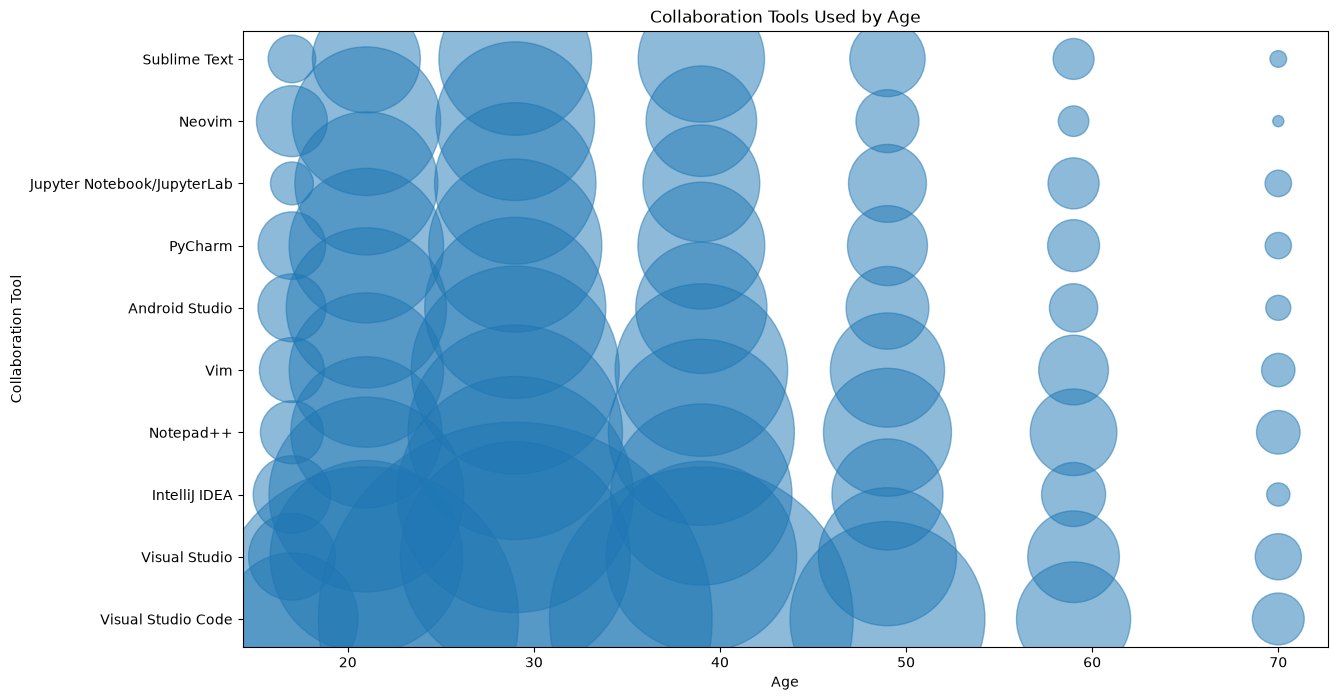

In [9]:
##Write your code here
# Select required columns
tools_data = df[
    [
        "Age_numeric",
        "NEWCollabToolsHaveWorkedWith"
    ]
].dropna()

# Split multiple collaboration tools
tools_data["Tool"] = (
    tools_data["NEWCollabToolsHaveWorkedWith"]
    .str.split(";")
)

tools_data = tools_data.explode(
    "Tool"
)

tools_data["Tool"] = (
    tools_data["Tool"]
    .str.strip()
)

# Count tool usage by age
tool_counts = (
    tools_data
    .groupby(["Age_numeric", "Tool"])
    .size()
    .reset_index(name="Frequency")
)

# Find top 10 tools
top_tools = (
    tools_data["Tool"]
    .value_counts()
    .head(10)
    .index
)

tool_counts = tool_counts[
    tool_counts["Tool"].isin(top_tools)
]

# Create tool positions
tool_positions = {
    tool: i
    for i, tool in enumerate(top_tools)
}

tool_counts["Tool_Position"] = (
    tool_counts["Tool"]
    .map(tool_positions)
)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    tool_counts["Age_numeric"],
    tool_counts["Tool_Position"],
    s=tool_counts["Frequency"] * 5,
    alpha=0.5
)

plt.title(
    "Collaboration Tools Used by Age"
)

plt.xlabel("Age")
plt.ylabel("Collaboration Tool")

plt.yticks(
    range(len(top_tools)),
    top_tools
)

plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



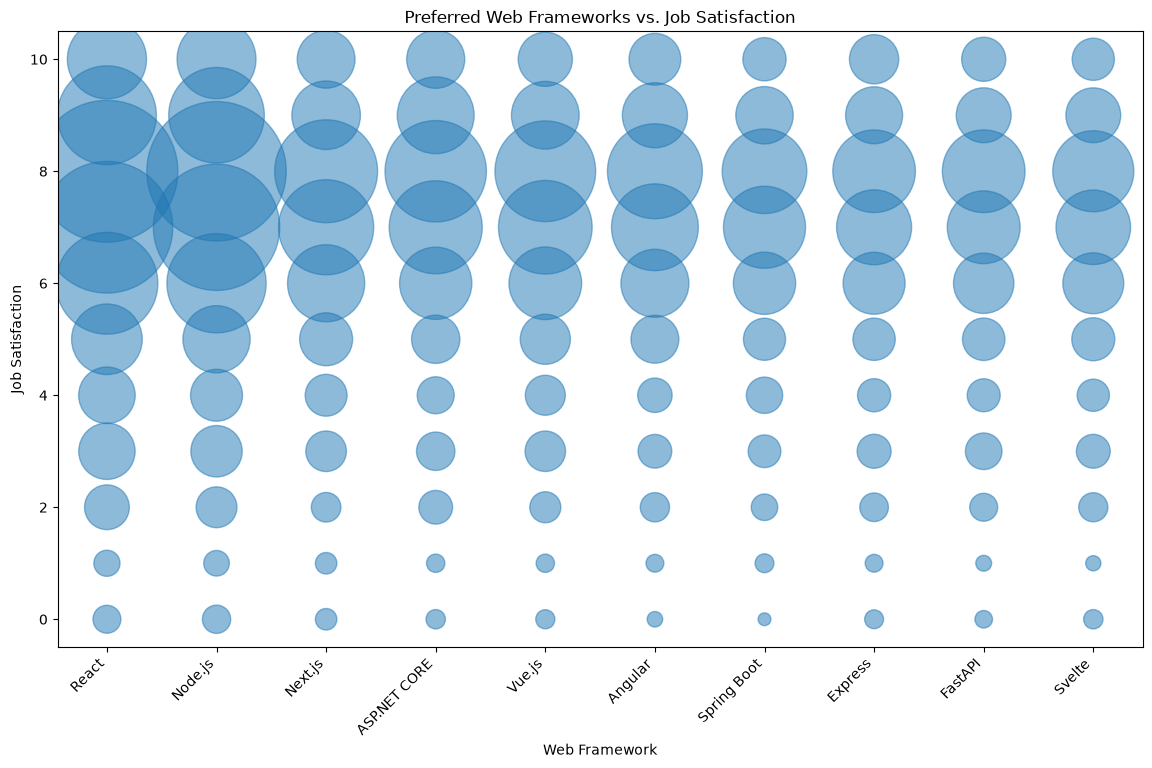

In [10]:
##Write your code here
# Select required data
framework_data = df[
    [
        "WebframeWantToWorkWith",
        "JobSat_numeric"
    ]
].dropna()

# Split multiple frameworks
framework_data["Framework"] = (
    framework_data["WebframeWantToWorkWith"]
    .str.split(";")
)

framework_data = framework_data.explode(
    "Framework"
)

framework_data["Framework"] = (
    framework_data["Framework"]
    .str.strip()
)

# Calculate frequency
framework_summary = (
    framework_data
    .groupby(["Framework", "JobSat_numeric"])
    .size()
    .reset_index(name="Frequency")
)

# Select top 10 frameworks
top_frameworks = (
    framework_data["Framework"]
    .value_counts()
    .head(10)
    .index
)

framework_summary = framework_summary[
    framework_summary["Framework"].isin(
        top_frameworks
    )
]

# Create positions
framework_positions = {
    framework: i
    for i, framework in enumerate(top_frameworks)
}

framework_summary["Framework_Position"] = (
    framework_summary["Framework"]
    .map(framework_positions)
)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    framework_summary["Framework_Position"],
    framework_summary["JobSat_numeric"],
    s=framework_summary["Frequency"] * 5,
    alpha=0.5
)

plt.title(
    "Preferred Web Frameworks vs. Job Satisfaction"
)

plt.xlabel("Web Framework")
plt.ylabel("Job Satisfaction")

plt.xticks(
    range(len(top_frameworks)),
    top_frameworks,
    rotation=45,
    ha="right"
)

plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



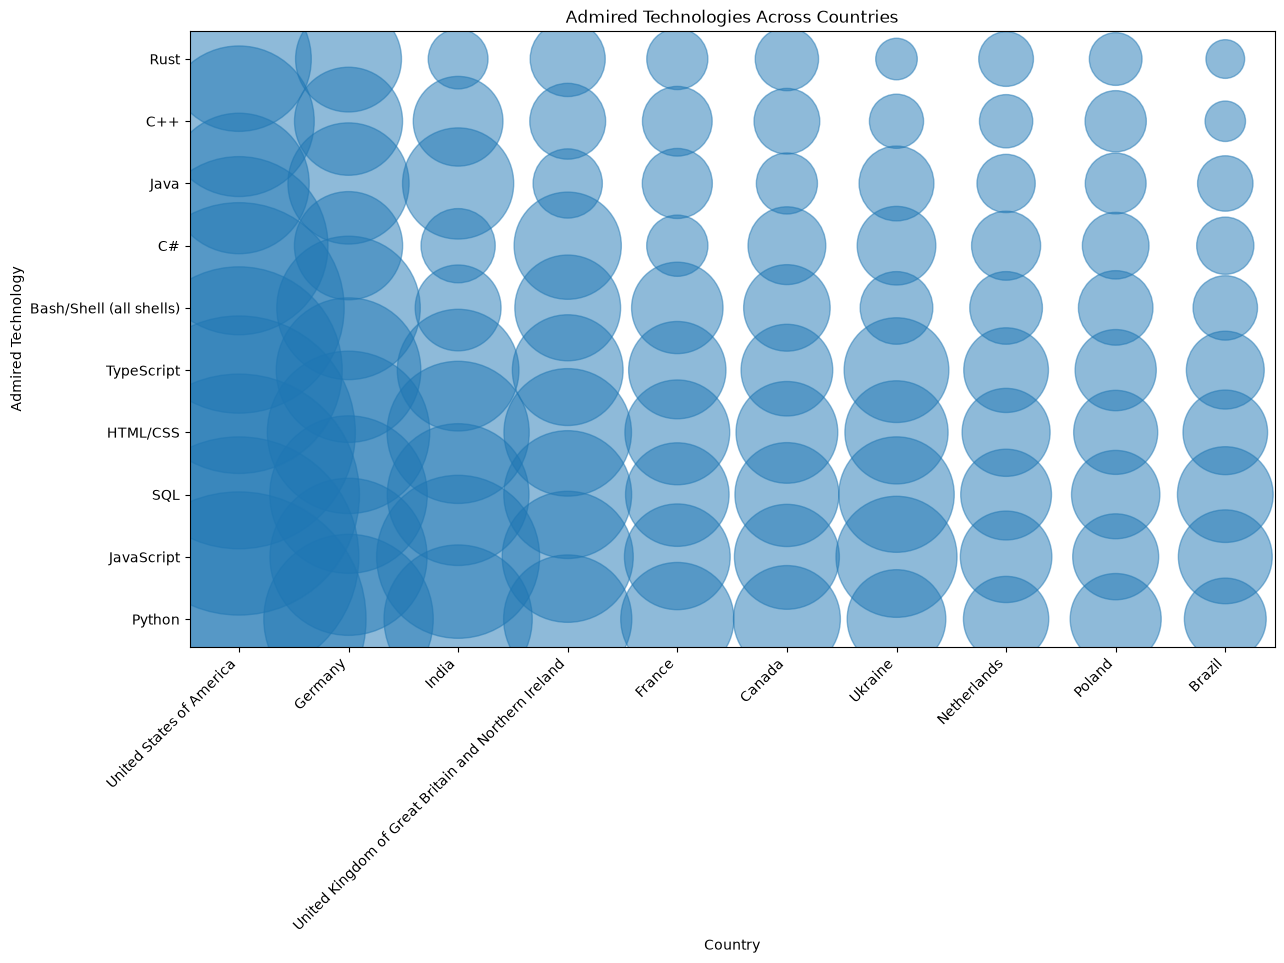

In [11]:
##Write your code here
# Select required columns
tech_data = df[
    [
        "Country",
        "LanguageAdmired"
    ]
].dropna()

# Split multiple admired technologies
tech_data["Technology"] = (
    tech_data["LanguageAdmired"]
    .str.split(";")
)

tech_data = tech_data.explode(
    "Technology"
)

tech_data["Technology"] = (
    tech_data["Technology"]
    .str.strip()
)

# Find top 10 countries
top_countries = (
    tech_data["Country"]
    .value_counts()
    .head(10)
    .index
)

tech_data = tech_data[
    tech_data["Country"].isin(
        top_countries
    )
]

# Find top 10 admired technologies
top_technologies = (
    tech_data["Technology"]
    .value_counts()
    .head(10)
    .index
)

tech_data = tech_data[
    tech_data["Technology"].isin(
        top_technologies
    )
]

# Count admiration by country and technology
tech_summary = (
    tech_data
    .groupby(["Country", "Technology"])
    .size()
    .reset_index(name="Frequency")
)

# Create numeric positions
country_positions = {
    country: i
    for i, country in enumerate(top_countries)
}

technology_positions = {
    technology: i
    for i, technology in enumerate(top_technologies)
}

tech_summary["Country_Position"] = (
    tech_summary["Country"]
    .map(country_positions)
)

tech_summary["Technology_Position"] = (
    tech_summary["Technology"]
    .map(technology_positions)
)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    tech_summary["Country_Position"],
    tech_summary["Technology_Position"],
    s=tech_summary["Frequency"] * 8,
    alpha=0.5
)

plt.title(
    "Admired Technologies Across Countries"
)

plt.xlabel("Country")
plt.ylabel("Admired Technology")

plt.xticks(
    range(len(top_countries)),
    top_countries,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(top_technologies)),
    top_technologies
)

plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
